### imports

In [1]:
import os
import random
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from keras.utils import Sequence
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1788853866.498177  199481 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788853866.784305  199481 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788853868.034708  199481 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Parameters

In [2]:
DATA_DIR = r'/home/arc/Code/eq_idn/oneforall'
CATEGORIES = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9','+', '-', '*', '%', '[', ']']
IMG_SIZE = 28
BATCH_SIZE = 64
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

#### load images function

In [3]:
def load_raw_data(data_dir, categories):
    images, labels = [], []
    for category in categories:
        label = categories.index(category)
        folder = os.path.join(data_dir, category)
        for fname in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            if img.shape != (IMG_SIZE, IMG_SIZE):
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            images.append(img)
            labels.append(label)
    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.int64)

In [4]:
X_raw, y = load_raw_data(DATA_DIR, CATEGORIES)
print(f"Loaded {len(X_raw)} images across {len(set(y))} classes.")

Loaded 333895 images across 16 classes.


#### Stratified split

In [5]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.3, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

#### Class Weights

In [6]:
class_weight_values = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {cls: w for cls, w in zip(np.unique(y_train), class_weight_values)}
print("Class weights:", {CATEGORIES[k]: round(v, 2) for k, v in class_weight_dict.items()})

Class weights: {'0': np.float64(1.03), '1': np.float64(1.02), '2': np.float64(1.02), '3': np.float64(0.96), '4': np.float64(0.96), '5': np.float64(1.01), '6': np.float64(1.01), '7': np.float64(1.06), '8': np.float64(1.01), '9': np.float64(1.02), '+': np.float64(0.94), '-': np.float64(0.98), '*': np.float64(1.03), '%': np.float64(0.86), '[': np.float64(1.03), ']': np.float64(1.09)}


#### Augumentation function

In [7]:
def augment_image(img):
    out = img.copy()
    r = random.random()
    if r < 0.35:
        k = random.choice([2, 3])
        kernel = np.ones((k, k), np.uint8)
        out = cv2.erode(out, kernel, iterations=1)   # thicker
    elif r < 0.55:
        k = random.choice([2, 3])
        kernel = np.ones((k, k), np.uint8)
        out = cv2.dilate(out, kernel, iterations=1)   # thinner
    #else:leave stroke width as-is

    #small rotation, shift, zoom
    h, w = out.shape
    angle = random.uniform(-12, 12)
    scale = random.uniform(0.9, 1.1)
    tx = random.uniform(-2, 2)
    ty = random.uniform(-2, 2)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=255)
    return out

In [8]:
class AugmentedSequence(Sequence):

    def __init__(self, images, labels, batch_size, augment=True, shuffle=True):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(images))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_imgs = self.images[batch_idx]
        batch_labels = self.labels[batch_idx]

        if self.augment:
            batch_imgs = np.array([augment_image(img) for img in batch_imgs])

        batch_imgs = batch_imgs.astype('float32') / 255.0
        batch_imgs = np.expand_dims(batch_imgs, axis=-1)
        return batch_imgs, batch_labels

In [9]:
def normalize_plain(images):
    images = images.astype('float32') / 255.0
    return np.expand_dims(images, axis=-1)

In [10]:
train_gen = AugmentedSequence(X_train_raw, y_train, BATCH_SIZE, augment=True, shuffle=True)
X_val = normalize_plain(X_val_raw)
X_test = normalize_plain(X_test_raw)

#### Model

In [11]:
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(CATEGORIES), activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

I0000 00:00:1788853906.371519  199481 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,480 (462.81 KB)

 Trainable params: 118,480 (462.81 KB)

 Non-trainable params: 0 (0.00 B)

#### Train

In [13]:
Epochs = 30
history = model.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=Epochs,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/30


/home/arc/Code/tensur/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1788853927.603818  199481 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788853928.499165  200553 service.cc:153] XLA service 0x7f449c03f3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788853928.499185  200553 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788853928.531101  200553 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCE

  60/3652 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.0820 - loss: 2.7558  

I0000 00:00:1788853934.758807  200553 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 837/3652 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4445 - loss: 1.7259

I0000 00:00:1788853937.124094  200555 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2369__.42
I0000 00:00:1788853937.281605  200555 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788853937.575627  200555 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788853937.902365  200555 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1788853938.390410

3652/3652 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - accuracy: 0.6151 - loss: 1.2309 - val_accuracy: 0.8922 - val_loss: 0.3467 - learning_rate: 0.0010
Epoch 2/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7189 - loss: 0.9101 - val_accuracy: 0.9069 - val_loss: 0.3017 - learning_rate: 0.0010
Epoch 3/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7385 - loss: 0.8425 - val_accuracy: 0.9201 - val_loss: 0.2580 - learning_rate: 0.0010
Epoch 4/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7485 - loss: 0.8071 - val_accuracy: 0.9145 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 5/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7554 - loss: 0.7817 - val_accuracy: 0.9266 - val_loss: 0.2355 - learning_rate: 0.0010
Epoch 6/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7602 - loss: 0.7665 - val_accuracy: 0.9296 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 7/30
3652/3652 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7639 - loss:

#### Evaluate

Overall test accuracy:0.9481281638145447  (loss:0.16319124400615692)
Per-class report:
              precision    recall  f1-score   support

           0      0.954     0.995     0.974      3037
           1      0.948     0.879     0.912      3058
           2      0.893     0.959     0.925      3081
           3      0.968     0.950     0.959      3265
           4      0.969     0.958     0.963      3254
           5      0.973     0.970     0.972      3104
           6      0.976     0.979     0.978      3090
           7      0.953     0.885     0.918      2962
           8      0.976     0.983     0.980      3096
           9      0.945     0.945     0.945      3067
           +      0.967     0.923     0.945      3313
           -      0.964     0.968     0.966      3196
           *      0.977     0.994     0.985      3048
           %      0.861     0.944     0.901      3625
           [      0.942     0.936     0.939      3025
           ]      0.925     0.898     0.911     

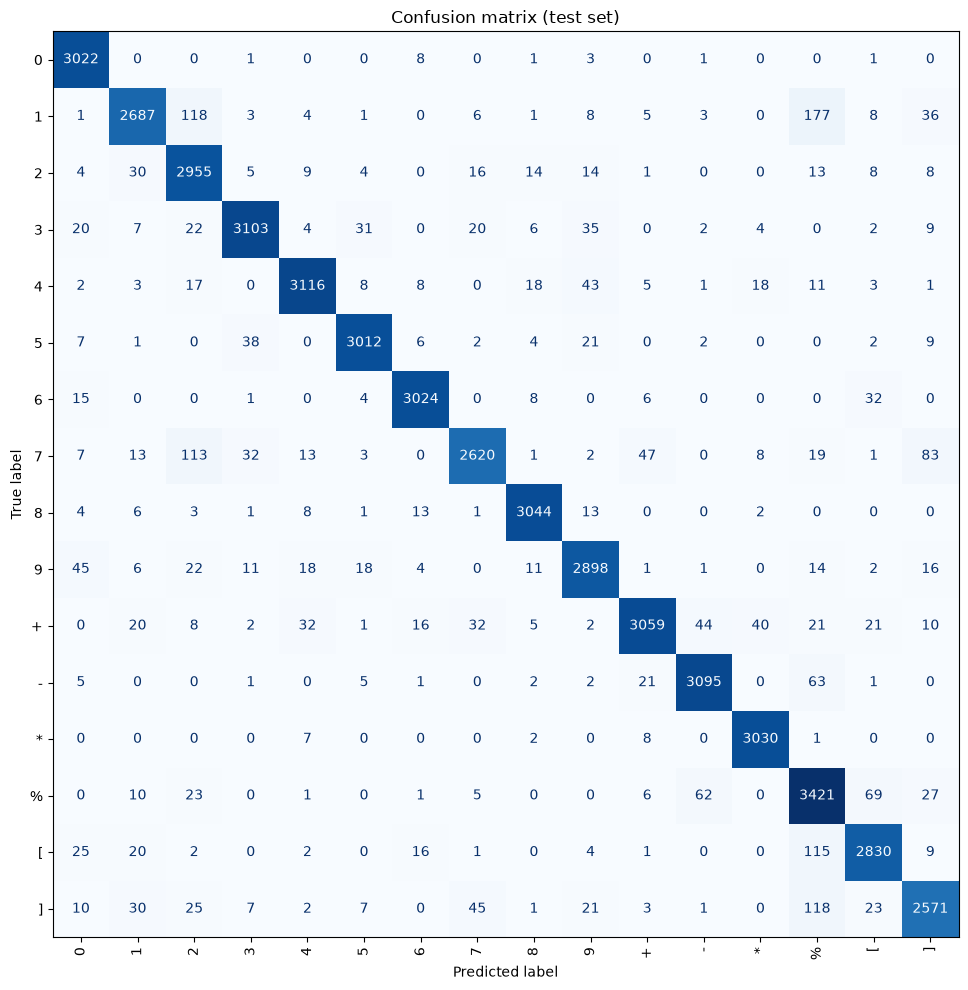

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Overall test accuracy:{test_acc}  (loss:{test_loss})")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Per-class report:")
print(classification_report(y_test, y_pred, target_names=CATEGORIES, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=range(len(CATEGORIES)))
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', colorbar=False)
plt.title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

### saving the modell

In [ ]:
model.save('equation_reader_v2.keras')